<a href="https://colab.research.google.com/github/Micky0771/Ai-Seven/blob/main/Copia_de_EVA12_Ecommerce_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Celda 1: Importar librerías
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

print("Librerías cargadas correctamente.")
print("Versión de scikit-learn:", sklearn.__version__)

Librerías cargadas correctamente.
Versión de scikit-learn: 1.6.1


In [ ]:
# Celda 2: Subir el dataset desde tu computador
from google.colab import files

print("Selecciona el archivo online_shoppers_intention.csv desde tu computador.")
uploaded = files.upload()

Selecciona el archivo online_shoppers_intention.csv desde tu computador.


Saving online_shoppers_intention.csv to online_shoppers_intention (1).csv


In [ ]:
# Celda 3: Exploración inicial del dataset
csv_path = "online_shoppers_intention.csv"
df = pd.read_csv(csv_path)

print("Dimensiones del dataset (filas, columnas):", df.shape)
print("\nNombres de las columnas:")
print(df.columns.tolist())

print("\nPrimeras 5 filas:")
display(df.head())

print("\nInformación general:")
df.info()

print("\nValores faltantes por columna:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("faltantes"))

Dimensiones del dataset (filas, columnas): (12330, 18)

Nombres de las columnas:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Primeras 5 filas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  

,faltantes
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


Conteo absoluto de Revenue:


,count
Revenue,
False,10422
True,1908



Porcentaje de cada clase:


,porcentaje
Revenue,
False,84.53
True,15.47


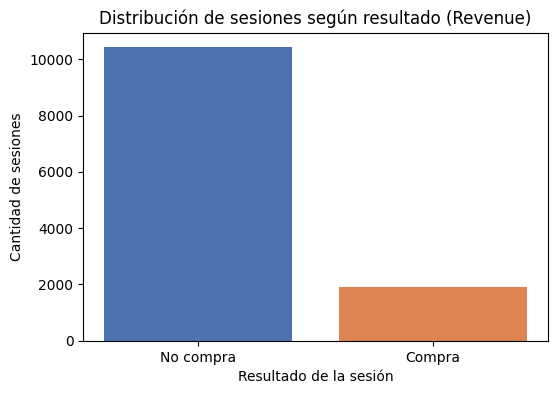

In [ ]:
# Celda 4: Distribución de la variable objetivo (compra / no compra)
print("Conteo absoluto de Revenue:")
display(df["Revenue"].value_counts())

print("\nPorcentaje de cada clase:")
display(df["Revenue"].value_counts(normalize=True).mul(100).round(2).to_frame("porcentaje"))

counts = df["Revenue"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["No compra", "Compra"], counts.values, color=["#4C72B0", "#DD8452"])
plt.title("Distribución de sesiones según resultado (Revenue)")
plt.ylabel("Cantidad de sesiones")
plt.xlabel("Resultado de la sesión")
plt.show()

In [ ]:
# Celda 5: Preparación de datos
np.random.seed(42)

X = df.drop(columns=["Revenue"])
y = df["Revenue"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)
print("\nProporción de compras en entrenamiento:")
print(y_train.value_counts(normalize=True).round(4))
print("\nProporción de compras en prueba:")
print(y_test.value_counts(normalize=True).round(4))

Variables numéricas: 14
Variables categóricas: 3
Entrenamiento: (9864, 17)
Prueba: (2466, 17)

Proporción de compras en entrenamiento:
Revenue
0    0.8453
1    0.1547
Name: proportion, dtype: float64

Proporción de compras en prueba:
Revenue
0    0.8451
1    0.1549
Name: proportion, dtype: float64


In [ ]:
# Celda 6: Entrenamiento del modelo Random Forest
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [ ]:
# Celda 7: Evaluación del modelo
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall":    recall_score(y_test, y_pred, zero_division=0),
    "F1-score":  f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC":   roc_auc_score(y_test, y_prob)
}

metrics_df = pd.DataFrame([metrics]).T.rename(columns={0: "Valor"})
metrics_df["Valor"] = metrics_df["Valor"].round(4)
display(metrics_df)

print("\nReporte de clasificación completo:")
print(classification_report(
    y_test, y_pred,
    target_names=["No compra", "Compra"],
    zero_division=0
))

,Valor
Accuracy,0.8978
Precision,0.7462
Recall,0.5157
F1-score,0.6099
ROC-AUC,0.9218



Reporte de clasificación completo:
              precision    recall  f1-score   support

   No compra       0.92      0.97      0.94      2084
      Compra       0.75      0.52      0.61       382

    accuracy                           0.90      2466
   macro avg       0.83      0.74      0.78      2466
weighted avg       0.89      0.90      0.89      2466



Matriz de confusión (valores absolutos):
[[2017   67]
 [ 185  197]]


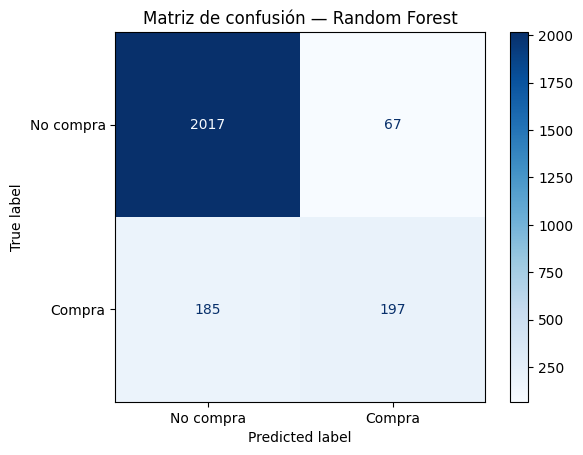

In [ ]:
# Celda 8: Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("Matriz de confusión (valores absolutos):")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No compra", "Compra"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión — Random Forest")
plt.show()

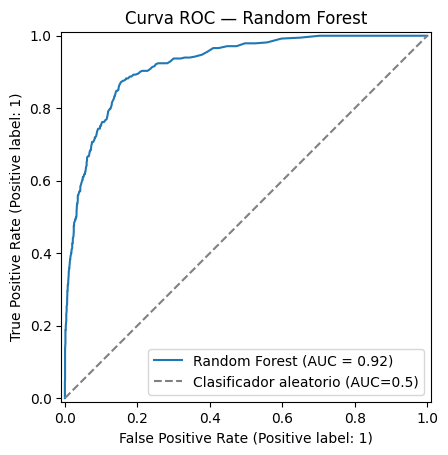

In [ ]:
# Celda 9: Curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob, name="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio (AUC=0.5)")
plt.title("Curva ROC — Random Forest")
plt.legend()
plt.show()

,Variable,Importancia
8,num__PageValues,0.382815
7,num__ExitRates,0.095264
5,num__ProductRelated_Duration,0.084191
4,num__ProductRelated,0.067000
6,num__BounceRates,0.056581
1,num__Administrative_Duration,0.049449
0,num__Administrative,0.037620
13,num__TrafficType,0.027261
21,cat__Month_Nov,0.026634
12,num__Region,0.026363


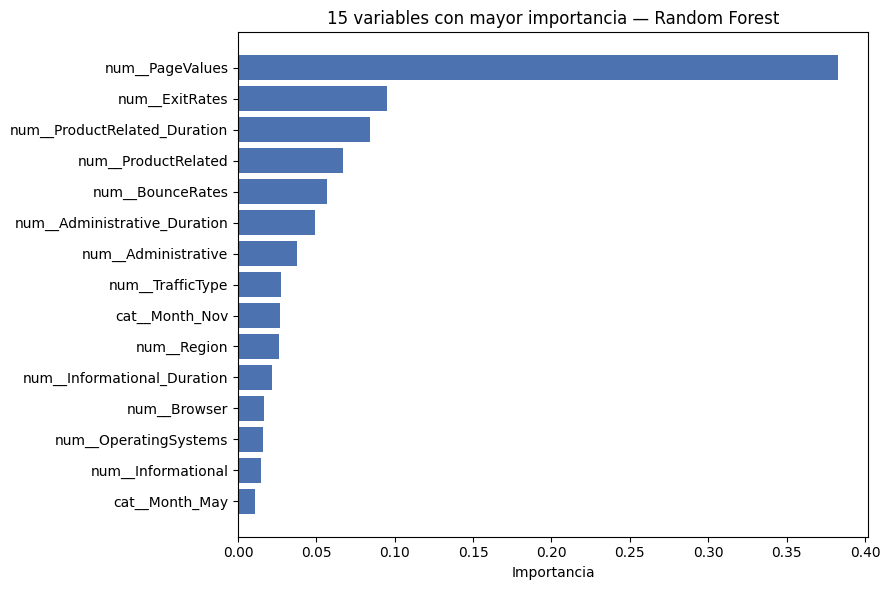

In [ ]:
# Celda 10: Importancia de variables
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
}).sort_values("Importancia", ascending=False).head(15)

display(importance_df)

plt.figure(figsize=(9, 6))
plt.barh(
    importance_df["Variable"][::-1],
    importance_df["Importancia"][::-1],
    color="#4C72B0"
)
plt.title("15 variables con mayor importancia — Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()